<a href="https://colab.research.google.com/github/BE7nHgA6/Brain-Tumor-MRI-Classification/blob/main/Tumour.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#Import libraries
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
!cp -r "/content/drive/MyDrive/train" /content/
!cp -r "/content/drive/MyDrive/valid" /content/
!cp -r "/content/drive/MyDrive/test" /content/

In [4]:
train_dir = "/content/train"
valid_dir = "/content/valid"
test_dir = "/content/test"

In [5]:
#check the folders

print("Test Classes:", os.listdir(test_dir))
print("Train Classes:", os.listdir(train_dir))
print("Validation Classes:", os.listdir(valid_dir))


Test Classes: ['_classes.csv', 'pituitary', 'no_tumor', 'meningioma', 'glioma']
Train Classes: ['_classes.csv', 'pituitary', 'glioma', 'no_tumor', 'meningioma']
Validation Classes: ['_classes.csv', 'glioma', 'no_tumor', 'meningioma', 'pituitary']


In [ ]:
#check test and validation counts

print("TEST DATA")
for cls in os.listdir(test_dir):
    path = os.path.join(test_dir, cls)

    if os.path.isdir(path):
        print(cls, len(os.listdir(path)))

pituitary 54
no_tumor 49
meningioma 63
glioma 80


In [ ]:
#check train and validation counts
print("TRAIN DATA")

for cls in os.listdir(train_dir):
    path = os.path.join(train_dir, cls)

    if os.path.isdir(path):
        print(cls, len(os.listdir(path)))


TRAIN DATA
pituitary 438
glioma 564
no_tumor 335
meningioma 358


In [ ]:
#check valid and validation counts
print("VALID DATA")

for cls in os.listdir(valid_dir):
    path = os.path.join(valid_dir, cls)

    if os.path.isdir(path):
        print(cls, len(os.listdir(path)))

VALID DATA
glioma 161
no_tumor 99
meningioma 124
pituitary 118


In [6]:
#Data Preprocessing & Data Augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

valid_datagen = ImageDataGenerator(rescale=1./255)

test_datagen = ImageDataGenerator(rescale=1./255)

In [7]:
#Create Generators
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 1695 images belonging to 4 classes.


In [9]:
valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 502 images belonging to 4 classes.


In [11]:
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128,128),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 246 images belonging to 4 classes.


In [12]:
#check the generator
print(train_generator.class_indices)
print(valid_generator.class_indices)
print(test_generator.class_indices)

{'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}
{'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}
{'glioma': 0, 'meningioma': 1, 'no_tumor': 2, 'pituitary': 3}


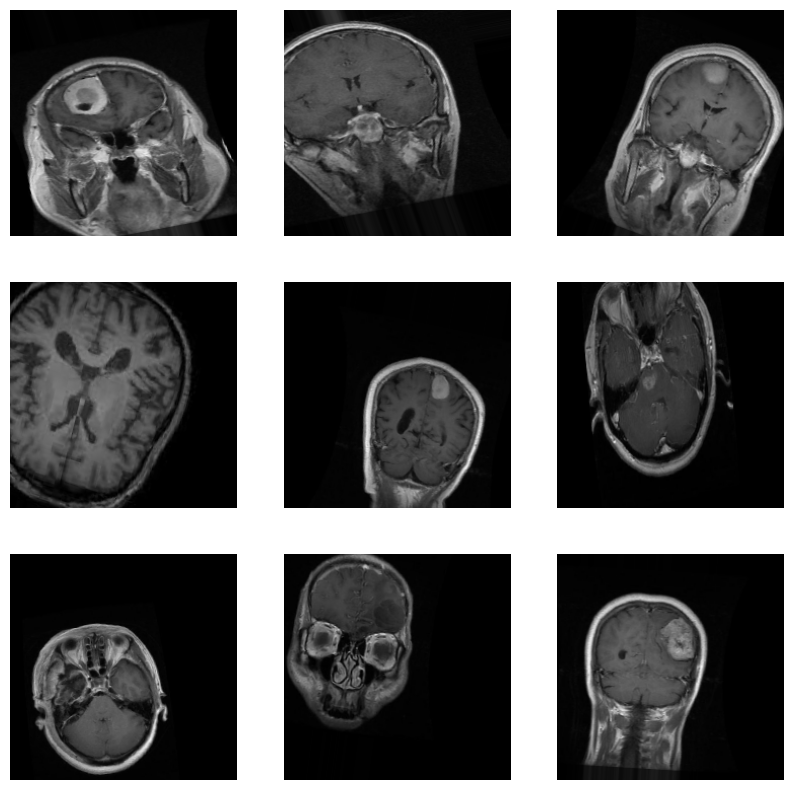

In [ ]:
#visualization
images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.axis("off")

plt.show()

In [13]:
#Build Custom CNN Model
#Import Required Libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization

In [14]:
#Build CNN Architecture
cnn_model = Sequential()

# Block 1
cnn_model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

cnn_model.add(BatchNormalization())

cnn_model.add(MaxPooling2D(pool_size=(2,2)))

# Block 2
cnn_model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

cnn_model.add(BatchNormalization())

cnn_model.add(MaxPooling2D(pool_size=(2,2)))

# Block 3
cnn_model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

cnn_model.add(BatchNormalization())

cnn_model.add(MaxPooling2D(pool_size=(2,2)))

cnn_model.add(GlobalAveragePooling2D())


# Dense Layer
cnn_model.add(Dense(128, activation='relu'))

cnn_model.add(Dropout(0.5))

# Output Layer (4 classes)
cnn_model.add(Dense(4, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
#View Model Summary
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 126, 126, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 28, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,172 (434.27 KB)

 Trainable params: 110,724 (432.52 KB)

 Non-trainable params: 448 (1.75 KB)

In [16]:
#compile model
cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
#create call backs
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

In [18]:
#Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [19]:
#save the best model
checkpoint = ModelCheckpoint(
    'custom_cnn_best.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [21]:
history = cnn_model.fit(
    train_generator,
    validation_data=valid_generator,
   epochs=10,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 547ms/step - accuracy: 0.6722 - loss: 0.8379
Epoch 1: val_accuracy improved from 0.44024 to 0.55976, saving model to custom_cnn_best.h5



Epoch 1: finished saving model to custom_cnn_best.h5
53/53 ━━━━━━━━━━━━━━━━━━━━ 32s 606ms/step - accuracy: 0.6855 - loss: 0.8173 - val_accuracy: 0.5598 - val_loss: 1.4007
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 543ms/step - accuracy: 0.7198 - loss: 0.7175
Epoch 2: val_accuracy did not improve from 0.55976
53/53 ━━━━━━━━━━━━━━━━━━━━ 31s 592ms/step - accuracy: 0.7233 - loss: 0.7144 - val_accuracy: 0.3068 - val_loss: 1.7356
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 550ms/step - accuracy: 0.7446 - loss: 0.6555
Epoch 3: val_accuracy did not improve from 0.55976
53/53 ━━━━━━━━━━━━━━━━━━━━ 32s 605ms/step - accuracy: 0.7528 - loss: 0.6483 - val_accuracy: 0.2490 - val_loss: 2.3311
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 588ms/step - accuracy: 0.7581 - loss: 0.6358
Epoch 4: val_accuracy did not improve from 0.55976
53/53 ━━━━━━━━━━━━━━━━━━━━ 35s 647ms/step - accuracy: 0.7463 - loss: 0.6572 - val_accuracy: 0.4821 - val_loss: 2.1435
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 0s 561ms/step - accuracy:

In [22]:
#save the model
from tensorflow.keras.models import load_model

best_model = load_model("custom_cnn_best.h5")

In [23]:
#check the test accuracy
test_loss, test_acc = best_model.evaluate(test_generator)

print("Test Accuracy:", test_acc)

8/8 ━━━━━━━━━━━━━━━━━━━━ 89s 12s/step - accuracy: 0.4878 - loss: 1.4081
Test Accuracy: 0.4878048896789551


In [41]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.efficientnet import preprocess_input

In [42]:
#train generator
train_datagen_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

In [43]:
#validation generator
valid_datagen_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [44]:
#test generator
test_datagen_eff = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

In [45]:
#create generator
train_generator_eff = train_datagen_eff.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 1695 images belonging to 4 classes.


In [46]:
#valid generator
valid_generator_eff = valid_datagen_eff.flow_from_directory(
    valid_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 502 images belonging to 4 classes.


In [47]:
#test generator
test_generator_eff = test_datagen_eff.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 246 images belonging to 4 classes.


In [48]:
#Build EfficientNet
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

In [49]:
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

In [50]:

#freeze the base
base_model.trainable = False

In [51]:
#build
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu')(x)

x = Dropout(0.3)(x)

outputs = Dense(4, activation='softmax')(x)

efficient_model = Model(
    inputs=base_model.input,
    outputs=outputs
)

In [52]:
#compile
from tensorflow.keras.optimizers import Adam

efficient_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [53]:
history_eff = efficient_model.fit(
    train_generator_eff,
    validation_data=valid_generator_eff,
    epochs=10
)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 75s 999ms/step - accuracy: 0.5864 - loss: 1.0355 - val_accuracy: 0.6633 - val_loss: 0.7899
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 31s 585ms/step - accuracy: 0.7581 - loss: 0.6866 - val_accuracy: 0.7390 - val_loss: 0.6234
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 33s 617ms/step - accuracy: 0.8018 - loss: 0.5676 - val_accuracy: 0.7888 - val_loss: 0.5308
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 31s 586ms/step - accuracy: 0.8330 - loss: 0.4997 - val_accuracy: 0.8048 - val_loss: 0.4938
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 31s 589ms/step - accuracy: 0.8330 - loss: 0.4500 - val_accuracy: 0.8207 - val_loss: 0.4574
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 31s 589ms/step - accuracy: 0.8572 - loss: 0.4079 - val_accuracy: 0.8486 - val_loss: 0.4167
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 33s 626ms/step - accuracy: 0.8614 - loss: 0.3813 - val_accuracy: 0.8446 - val_loss: 0.4171
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 31s 584ms/step - accuracy: 0.8720 - loss: 0.3685 - val_accu

In [54]:
print(history_eff.history['accuracy'])
print(history_eff.history['val_accuracy'])

[0.5864306688308716, 0.7581120729446411, 0.8017699122428894, 0.833038330078125, 0.833038330078125, 0.8572271466255188, 0.8613569140434265, 0.871976375579834, 0.8843657970428467, 0.8672566413879395]
[0.6633465886116028, 0.7390438318252563, 0.788844645023346, 0.804780900478363, 0.8207171559333801, 0.8486055731773376, 0.8446215391159058, 0.8745020031929016, 0.8725099563598633, 0.850597620010376]


In [55]:
#evaluate on test data
test_loss, test_acc = efficient_model.evaluate(test_generator_eff)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/step - accuracy: 0.8252 - loss: 0.4429
Test Accuracy: 0.8252032399177551
Test Loss: 0.442949503660202


In [56]:
#classification report
import numpy as np
from sklearn.metrics import classification_report

pred_probs = efficient_model.predict(test_generator_eff)

pred_classes = np.argmax(pred_probs, axis=1)

true_classes = test_generator_eff.classes

print(classification_report(
    true_classes,
    pred_classes
))

8/8 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step
              precision    recall  f1-score   support

           0       0.87      0.89      0.88        80
           1       0.80      0.63      0.71        63
           2       0.93      0.78      0.84        49
           3       0.74      1.00      0.85        54

    accuracy                           0.83       246
   macro avg       0.83      0.82      0.82       246
weighted avg       0.83      0.83      0.82       246



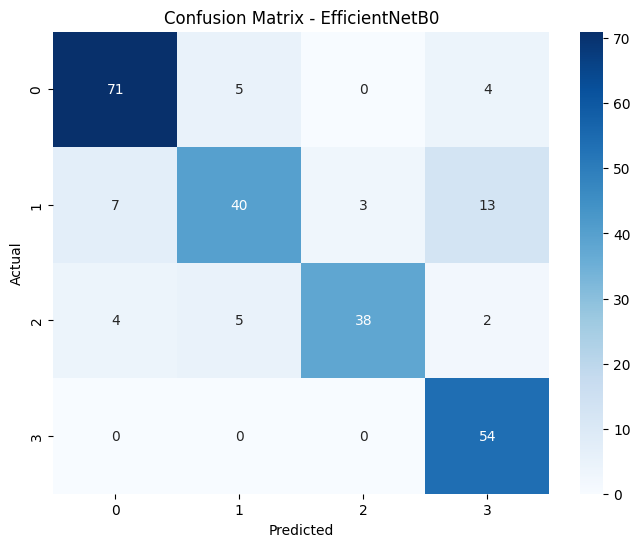

In [57]:
#confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - EfficientNetB0")

plt.show()

In [58]:
#save the model
efficient_model.save("brain_tumor_efficientnet.keras")

In [59]:
from google.colab import files
files.download("brain_tumor_efficientnet.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

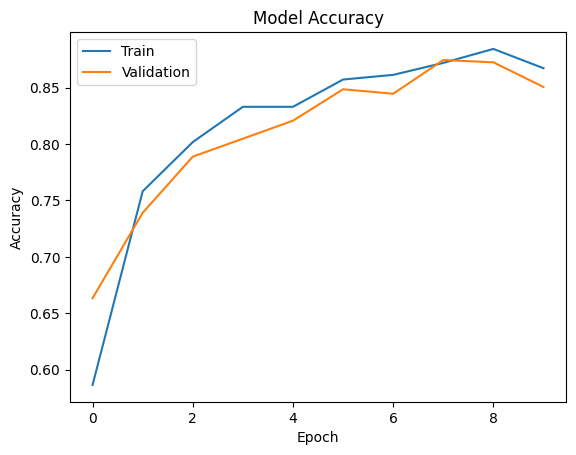

In [60]:
#accuracy and loss graphs
import matplotlib.pyplot as plt

plt.plot(history_eff.history['accuracy'])
plt.plot(history_eff.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

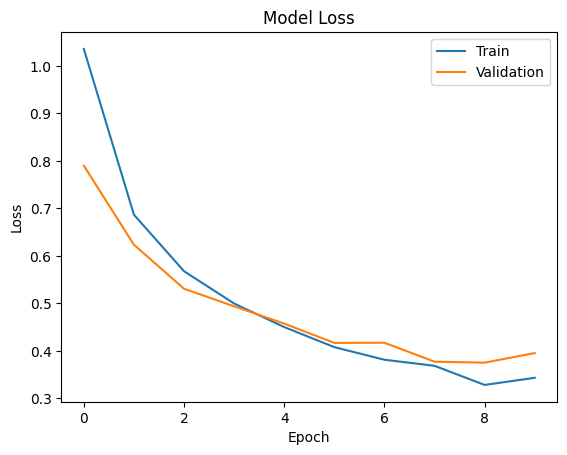

In [61]:
plt.plot(history_eff.history['loss'])
plt.plot(history_eff.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

In [62]:
#evaluate the dataset
test_loss, test_acc = efficient_model.evaluate(test_generator_eff)

print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 289ms/step - accuracy: 0.8252 - loss: 0.4429
Test Accuracy: 0.8252032399177551
Test Loss: 0.442949503660202


In [63]:
#generate classification report
import numpy as np
from sklearn.metrics import classification_report

pred_probs = efficient_model.predict(test_generator_eff)

pred_classes = np.argmax(pred_probs, axis=1)

true_classes = test_generator_eff.classes

print(classification_report(true_classes, pred_classes))

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 237ms/step
              precision    recall  f1-score   support

           0       0.87      0.89      0.88        80
           1       0.80      0.63      0.71        63
           2       0.93      0.78      0.84        49
           3       0.74      1.00      0.85        54

    accuracy                           0.83       246
   macro avg       0.83      0.82      0.82       246
weighted avg       0.83      0.83      0.82       246



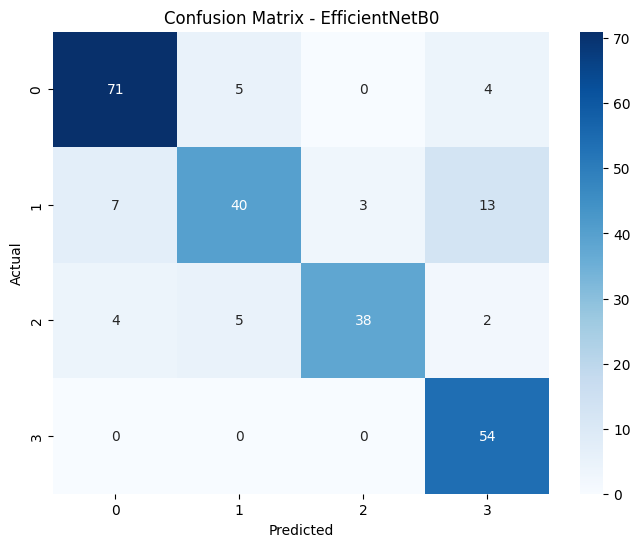

In [64]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - EfficientNetB0")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

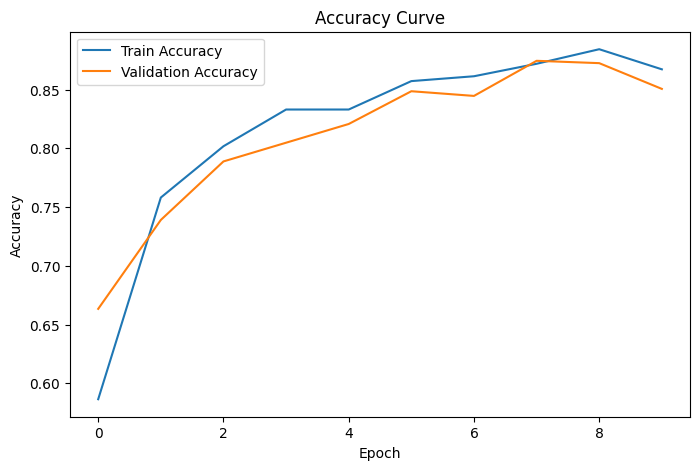

In [65]:
#accuracy graph
plt.figure(figsize=(8,5))

plt.plot(history_eff.history['accuracy'], label='Train Accuracy')
plt.plot(history_eff.history['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

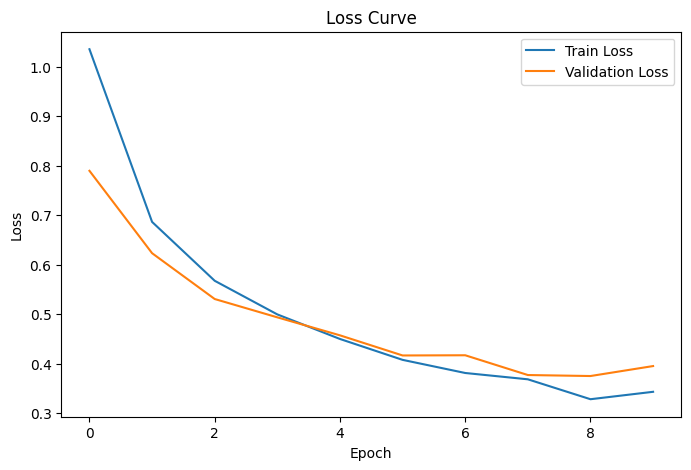

In [66]:
#loss graph
plt.figure(figsize=(8,5))

plt.plot(history_eff.history['loss'], label='Train Loss')
plt.plot(history_eff.history['val_loss'], label='Validation Loss')

plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [67]:
efficient_model.save("brain_tumor_efficientnet.keras")

In [68]:
import shutil

shutil.copy(
    "brain_tumor_efficientnet.keras",
    "/content/drive/MyDrive/brain_tumor_efficientnet.keras"
)

'/content/drive/MyDrive/brain_tumor_efficientnet.keras'

In [69]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Custom CNN", "EfficientNetB0"],
    "Accuracy": [0.49, test_acc]
})

comparison

,Model,Accuracy
0,Custom CNN,0.490000
1,EfficientNetB0,0.825203


In [70]:
test_loss, test_acc = efficient_model.evaluate(test_generator_eff)

print(test_acc)

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 186ms/step - accuracy: 0.8252 - loss: 0.4429
0.8252032399177551


In [71]:
#streamlit
!pip install -q streamlit
!wget https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared-linux-amd64
import subprocess
subprocess.Popen(["./cloudflared-linux-amd64", "tunnel", "--url", "http://localhost:8501"])
!nohup /content/cloudflared-linux-amd64 tunnel --url http://localhost:8501 &

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 75.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 123.6 MB/s eta 0:00:00
--2026-06-05 17:19:13--  https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/cloudflare/cloudflared/releases/download/2026.5.2/cloudflared-linux-amd64 [following]
--2026-06-05 17:19:13--  https://github.com/cloudflare/cloudflared/releases/download/2026.5.2/cloudflared-linux-amd64
Reusing existing connection to github.com:443.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/106867604/49ed726b-742b-4dbe-a0cf-d9efc4d22773?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-06-05T18%3A15%3A43Z&rscd=attachment%3B+filename%3Dc

In [72]:
!pip install streamlit-option-menu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.3/829.3 kB 18.3 MB/s eta 0:00:00


In [82]:
!streamlit run /content/app.py &>/content/logs.txt &

In [75]:
!grep -o 'https://.*\.trycloudflare.com' nohup.out | head -n 1 | xargs -I {} echo "Your tunnel url {}"

Your tunnel url https://crossword-atlas-effective-seeking.trycloudflare.com


In [81]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image
from tensorflow.keras.applications.efficientnet import preprocess_input

# Load Model
model = tf.keras.models.load_model("brain_tumor_efficientnet.keras")

# Class Names
classes = [
    "glioma",
    "meningioma",
    "no_tumor",
    "pituitary"
]

st.set_page_config(page_title="Brain Tumor Classification")

st.title("🧠 Brain Tumor MRI Classification")

st.write(
    "Upload an MRI image and the model will predict the tumor type."
)

uploaded_file = st.file_uploader(
    "Upload MRI Image",
    type=["jpg", "jpeg", "png"]
)

if uploaded_file is not None:

    image = Image.open(uploaded_file).convert("RGB")

    st.image(
        image,
        caption="Uploaded MRI Image",
        use_container_width=True
    )

    # Resize
    img = image.resize((224, 224))

    # Convert to Array
    img_array = np.array(img)

    # Expand Dimensions
    img_array = np.expand_dims(img_array, axis=0)

    # EfficientNet Preprocessing
    img_array = preprocess_input(img_array)

    # Prediction
    prediction = model.predict(img_array)

    predicted_class = np.argmax(prediction)

    confidence = np.max(prediction) * 100

    st.success(
        f"Prediction: {classes[predicted_class]}"
    )

    st.info(
        f"Confidence Score: {confidence:.2f}%"
    )

Overwriting app.py


In [80]:
import os

test_glioma = "/content/drive/MyDrive/test/glioma"

print(os.listdir(test_glioma)[:5])

['Tr-gl_0453_jpg.rf.ba60a5514d36db41411f4279f21f4bdd.jpg', 'Tr-gl_0136_jpg.rf.4dec754b071df3e424e8ec2b7f81b8a5.jpg', 'Tr-gl_0301_jpg.rf.9e87b3d71315a64cc5b1d1562a430008.jpg', 'Tr-gl_0145_jpg.rf.d3c502513655260a6addaf252fcec4b7.jpg', 'Tr-gl_0466_jpg.rf.5d94c0be6e42eb7b605239eff07747e3.jpg']


In [83]:
!zip -r brain_tumor_dataset.zip /content/train /content/valid /content/test

  adding: content/train/ (stored 0%)
  adding: content/train/_classes.csv (deflated 63%)
  adding: content/train/pituitary/ (stored 0%)
  adding: content/train/pituitary/Tr-pi_0014_jpg.rf.0b881db3ad9b6b86c5353dd3f9b2ecdc.jpg (deflated 2%)
  adding: content/train/pituitary/Tr-pi_0121_jpg.rf.436a67afcbe343d250f37c31bdbfbb82.jpg (deflated 1%)
  adding: content/train/pituitary/Tr-pi_0184_jpg.rf.427bc8b1377d570382db2c9bd915ac0d.jpg (deflated 1%)
  adding: content/train/pituitary/Tr-pi_0122_jpg.rf.74ea5ab7fe5107617bb7f6dc9f5e81df.jpg (deflated 1%)
  adding: content/train/pituitary/Tr-pi_0100_jpg.rf.0f7eb1d190481aab47bc4efe0ffdfd05.jpg (deflated 2%)
  adding: content/train/pituitary/Tr-pi_0042_jpg.rf.8009fe462f97edaffde6a4711ce089b4.jpg (deflated 1%)
  adding: content/train/pituitary/Tr-pi_0148_jpg.rf.7be504cb1282f76469a7bfb77e612337.jpg (deflated 2%)
  adding: content/train/pituitary/Tr-pi_0178_jpg.rf.40092dfe7f63c127baee62fa78c8da74.jpg (deflated 1%)
  adding: content/train/pituitary/Tr-pi_

In [84]:
from google.colab import files
files.download("brain_tumor_dataset.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>